# Data Preparations

### Library & Dependency

This section imports all libraries required for data manipulation,
visualization, preprocessing, and dataset persistence.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import pickle

sns.set_style("whitegrid")

### Dataset Loader

The dataset is loaded into a Pandas DataFrame.
Each row represents a tumor sample and each column
contains a medical measurement extracted from
breast cancer examinations.

In [3]:
df = pd.read_csv("../data/breast_cancer_raw.csv")

df.head

<bound method NDFrame.head of            id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0      842302         M        17.99         10.38          122.80     1001.0   
1      842517         M        20.57         17.77          132.90     1326.0   
2    84300903         M        19.69         21.25          130.00     1203.0   
3    84348301         M        11.42         20.38           77.58      386.1   
4    84358402         M        20.29         14.34          135.10     1297.0   
..        ...       ...          ...           ...             ...        ...   
564    926424         M        21.56         22.39          142.00     1479.0   
565    926682         M        20.13         28.25          131.20     1261.0   
566    926954         M        16.60         28.08          108.30      858.1   
567    927241         M        20.60         29.33          140.10     1265.0   
568     92751         B         7.76         24.54           47.92      181.0  

### Dataset Overview

This section provides a general overview of the dataset,
including dimensions, data types, and descriptive statistics.
These observations help identify potential data quality issues.

#### Shape

In [4]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 569
Columns: 33


#### Information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

#### Statistical Summary

In [6]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


### Missing Value Analysis

Missing value analysis is performed to determine whether
imputation techniques are required before model training.

In [7]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Unnamed: 32    569
dtype: int64

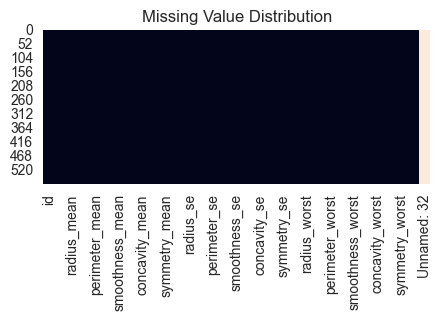

In [8]:
plt.figure(figsize=(5,2))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Distribution")
plt.show()

### Duplicate Data Analysis

Missing value analysis is performed to determine whether
imputation techniques are required before model training.

In [9]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


### Target Variable Analysis

Feature distributions are examined to understand
the spread, skewness, and overall behavior of
important medical measurements.

<function matplotlib.pyplot.show(close=None, block=None)>

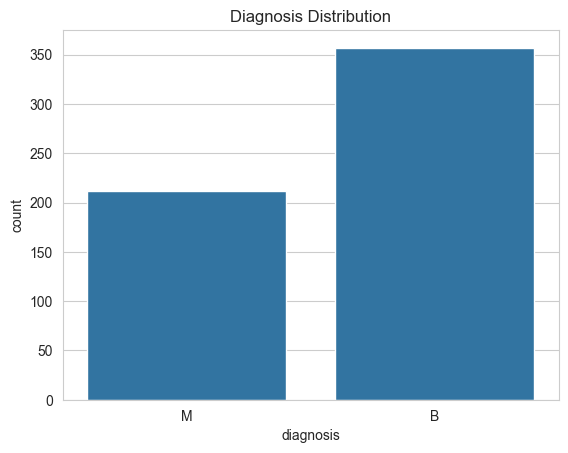

In [10]:
sns.countplot(data=df, x='diagnosis')
plt.title('Diagnosis Distribution')
plt.show

### Feature Distribution Analysis

Feature distributions are examined to understand
the spread, skewness, and overall behavior of
important medical measurements.

#### Radius Mean

<function matplotlib.pyplot.show(close=None, block=None)>

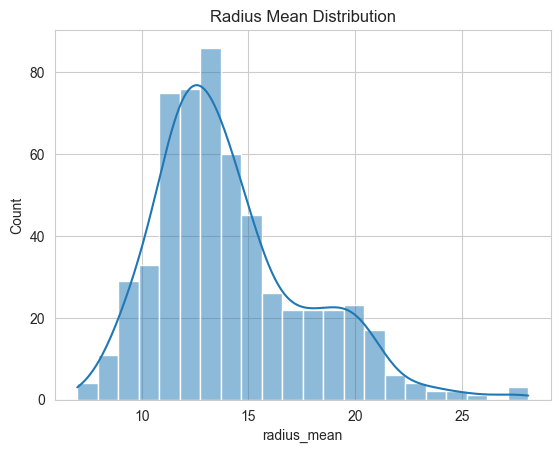

In [11]:
sns.histplot(df['radius_mean'], kde=True)
plt.title("Radius Mean Distribution")
plt.show

#### Texture Mean

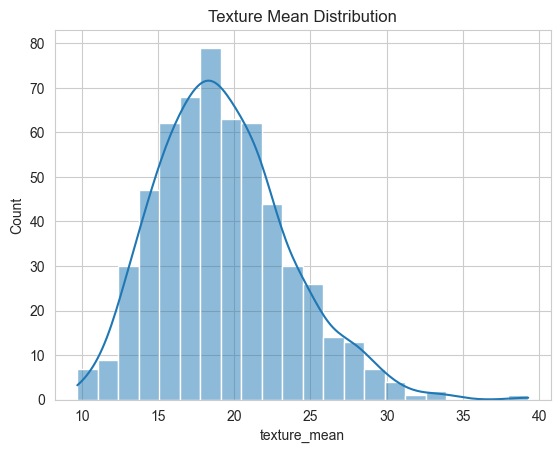

In [12]:
sns.histplot(df['texture_mean'], kde=True)
plt.title("Texture Mean Distribution")
plt.show()

#### Concavity Mean

<function matplotlib.pyplot.show(close=None, block=None)>

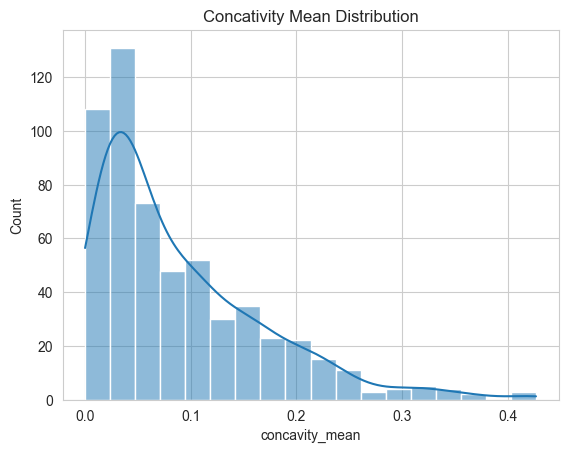

In [13]:
sns.histplot(df['concavity_mean'], kde=True)
plt.title("Concativity Mean Distribution")
plt.show

### Correlation Analysis

Correlation analysis identifies relationships between variables.
Highly correlated features may provide useful predictive information
or indicate redundancy within the dataset.

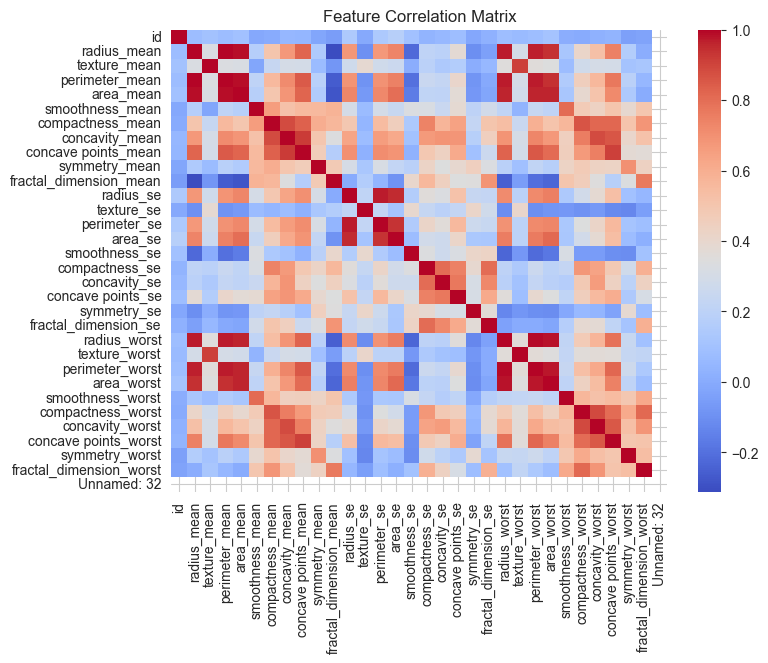

In [14]:
df_numeric = df.select_dtypes(include=np.number)

corr_matrix = df_numeric.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

### Data Cleaning

#### Removing Columns

The ID column contains unique identifiers that do not
contribute to prediction.

Unnamed: 32 is an empty column and therefore removed.

In [15]:
df = df.drop(columns=["id", "Unnamed: 32"])

#### Encode Target Variable

Machine learning algorithms require numerical targets.

M → 1
B → 0

In [16]:
df['diagnosis'] = df['diagnosis'].map({
    'M':1,
    'B':0
})

### Feature Engineering

#### Area Perimeter Ratio

This feature measures the relationship between tumor
area and perimeter, providing additional shape information.

In [17]:
df['area_perimeter_ratio'] = (
    df['area_mean'] /
    df['perimeter_mean']
)

#### Radius Growth Ratio

This feature estimates how much the tumor radius changes
between average and worst-case observations.

In [18]:
df['radius_growth_ratio'] = (
    df['radius_worst'] /
    df['radius_mean']
)

#### Concavity Score

A combined indicator representing the degree of
tumor irregularity and concavity.

In [19]:
df['concavity_score'] = (
    df['concavity_mean'] +
    df['concave points_mean']
)

### Feature Target Separation

The dataset is separated into predictors (X)
and target labels (y).

In [20]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

### Train-Test Split

The dataset is divided into training and testing subsets.

80% Training Data
20% Testing Data

Stratification preserves class proportions.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Feature Scaling

Standardization is applied after train-test splitting
to prevent data leakage.

Only training data is used to compute
the scaling parameters.

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### Save Data Prep

The processed dataset is saved for use
in the modeling notebook.

In [25]:
prepared_data = {
    "X_train": X_train_scaled,
    "X_test": X_test_scaled,
    "y_train": y_train,
    "y_test": y_test
}

with open("dataset/prepared_data.pkl", "wb") as f:
    pickle.dump(prepared_data, f)